In [43]:
import pandas as pd
import numpy as np

In [44]:
df = pd.read_csv("Sample - Superstore.csv",encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [45]:
df.info()
df.describe()
df.shape
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [46]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [47]:
df.duplicated().sum()
df = df.drop_duplicates()#remove duplicates

In [48]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [49]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

In [50]:
#vectorization better than apply
df['Profit_Category'] = np.where(df['Profit'] > 0, 'Profit', 'Loss')

In [62]:
#top category by sales
top_category =df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()
top_category

,Category,Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


In [63]:
# top categories by profit
profitable_category = df.groupby('Category')['Profit'].sum().sort_values()
profitable_category

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

In [52]:
#top 10 customers by sales
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10).reset_index()

In [54]:
#monthly sales trend
sales_by_month = df.groupby('Month')['Sales'].sum().reset_index()
sales_by_month

,Month,Sales
0,1,94924.8356
1,2,59751.2514
2,3,205005.4888
3,4,137762.1286
4,5,155028.8117
5,6,152718.6793
6,7,147238.0970
7,8,159044.0630
8,9,307649.9457
9,10,200322.9847


In [55]:
#region-wise sales
sales_by_region=df.groupby('Region')['Sales'].sum().reset_index()
sales_by_region

,Region,Sales
0,Central,501239.8908
1,East,678781.2400
2,South,391721.9050
3,West,725457.8245


In [67]:
#sales vs profit 
df.groupby('Category')[['Sales','Profit']].sum()

,Sales,Profit
Category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


In [56]:
#top 10 most profitable products
best_products =df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
best_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64

In [57]:
#running total
date_sorted = df.sort_values('Order Date')
df['Running_Sales'] = df['Sales'].cumsum()

In [58]:
#ranking customer by sales
df['Customer_Rank'] = df.groupby('Customer Name')['Sales'].transform('sum').rank(ascending=False)

In [66]:
#products by low profit
low_profitable_products = df[df['Profit'] < 0].groupby('Product Name')['Profit'].sum().sort_values().head(10)
low_profitable_products

Product Name
Cubify CubeX 3D Printer Double Head Print                                     -9239.9692
GBC DocuBind P400 Electric Binding System                                     -6859.3896
Lexmark MX611dhe Monochrome Laser Printer                                     -5269.9690
GBC Ibimaster 500 Manual ProClick Binding System                              -5098.5660
GBC DocuBind TL300 Electric Binding System                                    -4162.0336
Cubify CubeX 3D Printer Triple Head Print                                     -3839.9904
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind   -3431.6730
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases                      -3107.5272
Ibico EPK-21 Electric Binding System                                          -2929.4845
Bush Advantage Collection Racetrack Conference Table                          -2545.2600
Name: Profit, dtype: float64

In [69]:
#repeated customers
df['Customer Name'].value_counts().head(10)

Customer Name
William Brown          37
John Lee               34
Paul Prost             34
Matt Abelman           34
Seth Vernon            32
Edward Hooks           32
Jonathan Doherty       32
Chloris Kastensmidt    32
Arthur Prichep         31
Zuschuss Carroll       31
Name: count, dtype: int64

In [70]:
#average order value
df['Sales'].mean()

np.float64(229.85800083049827)

In [79]:
#correlation
df[['Sales','Profit','Quantity']].corr()

,Sales,Profit,Quantity
Sales,1.000000,0.479064,0.200795
Profit,0.479064,1.000000,0.066253
Quantity,0.200795,0.066253,1.000000


In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
sns.set(style="whitegrid")

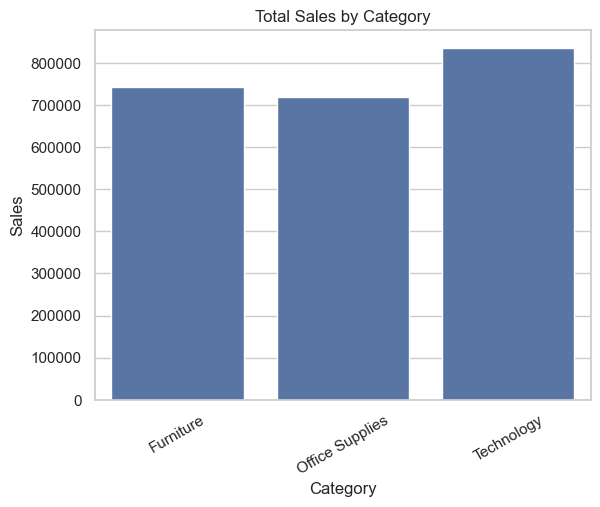

In [74]:
#sales by category
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure()
sns.barplot(x='Category', y='Sales', data=category_sales)
plt.title("Total Sales by Category")
plt.xticks(rotation=30)
plt.show()

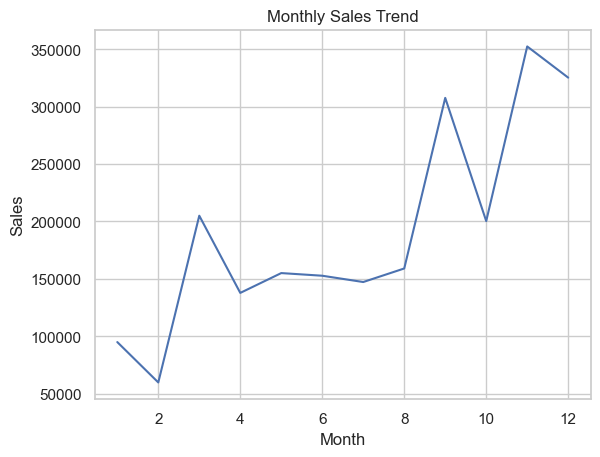

In [75]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()

plt.figure()
sns.lineplot(x='Month', y='Sales', data=monthly_sales)
plt.title("Monthly Sales Trend")
plt.show()

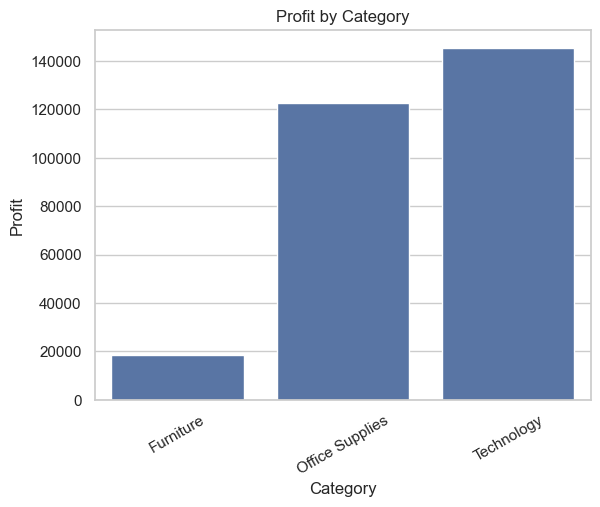

In [76]:
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

plt.figure()
sns.barplot(x='Category', y='Profit', data=category_profit)
plt.title("Profit by Category")
plt.xticks(rotation=30)
plt.show()

In [ ]:
## Key Insights
'''
- Technology category generates the highest sales, but profit varies across categories
- A small number of customers contribute a large portion of total revenue
- Some products consistently generate losses despite good sales
- Sales and profit are not always directly correlated
- Certain customers show repeat purchasing behavior
- Revenue trends show variation across months and regions
'''